# 11 · Observational causal inference — the assumption you can't test

**NB 11.** Every notebook so far has had an *experiment* somewhere — randomized assignment, a switchback,
a holdout. But most business questions arrive **observational**: spend was set by a manager, not a coin;
users self-selected into the feature; the campaign chased releases that were already hot. There was no
experiment, and there never will be one.

The promise of observational causal inference is **selection on observables** (*unconfoundedness*): *if*
we adjust for every confounder X that drives both treatment and outcome, a doubly-robust estimator
recovers the truth. The catch — the entire subject, really — is that **"every confounder" is an
assumption you cannot test from the data.** A hidden confounder leaves no footprint in the fit.

So this notebook is in two halves:
1. **The solvable half** — selection on *observables*. Naive and OLS bias; **AIPW / DML recover** (a quick
   recap; the machinery is already in `lyra.estimators` + `lyra.observational`).
2. **The honest half** — selection on *unobservables*. A hidden confounder breaks *every* estimator, and
   since we can't test for it, we **quantify our exposure to it**: the **robustness value**, the
   **omitted-variable-bias contour**, and the **E-value**. Then — the simulator superpower — because we
   *authored* the hidden confounder, we **validate the sensitivity analysis itself against ground truth.**

This is the general principle whose applied proof is the **music-marketing lab** (`labs/music-marketing/`):
an MMM is observational causal inference, spend endogeneity *is* confounding, and its identification study
is this very discipline run at scale.

## 1 · Setup

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import sys, pathlib; sys.path.insert(0, str(pathlib.Path.cwd().parent))

import nbtools; nbtools.set_style()
from nbtools import BLUE, GREEN, PINK, PURPLE, ORANGE, GRAY, forest

from lyra.dgp import DGPLevel1, covariate_cols
from lyra.estimators import DiffInMeans, OLSAdjust, AIPW
from lyra.observational import (DML, partial_r2, robustness_value, ovb_bias, adjusted_estimate,
                                ovb_contour, e_value_smd)
from lyra.harness import harness
sig = lambda z: 1 / (1 + np.exp(-z))

## 2 · The solvable half — selection on *observables*

Start where causal inference *works*. `DGPLevel1` assigns treatment with a propensity that depends on the
same covariates X that drive the outcome (a **confounding knob**), and a **nonlinear** baseline. This is
textbook selection-on-observables: nothing is hidden, but the assignment is not random.

Four estimators, same data:
- **diff-in-means** — ignores X → biased by confounding;
- **OLS** — *linear* adjustment → still biased when the baseline is nonlinear;
- **AIPW** (hand-rolled, cross-fitted) and **DML** (`econml`) — **doubly robust** → recover the truth.

In [2]:
dgp_obs = DGPLevel1(d=5, ate=2.0, sigma=1.0, confounding=1.2, nonlinear=True)
df_obs = dgp_obs.sample(6000, seed=1)
TRUTH = dgp_obs.ground_truth().ate

res_obs = [e.estimate(df_obs) for e in (DiffInMeans(), OLSAdjust(), AIPW(), DML())]
tbl = pd.DataFrame({
    "estimator": [r.estimator for r in res_obs],
    "estimate": [r.point for r in res_obs],
    "95% CI": [f"[{r.ci[0]:+.2f}, {r.ci[1]:+.2f}]" for r in res_obs],
    "bias": [r.point - TRUTH for r in res_obs],
    "covers truth": [r.covers(TRUTH) for r in res_obs],
}).round(3)
print(f"TRUTH ate = {TRUTH}  (confounded assignment + nonlinear baseline)")
tbl

TRUTH ate = 2.0  (confounded assignment + nonlinear baseline)


,estimator,estimate,95% CI,bias,covers truth
0,diff,3.916,"[+3.78, +4.05]",1.916,False
1,ols,3.317,"[+3.18, +3.46]",1.317,False
2,aipw,1.988,"[+1.86, +2.11]",-0.012,True
3,dml,1.912,"[+1.85, +1.98]",-0.088,False


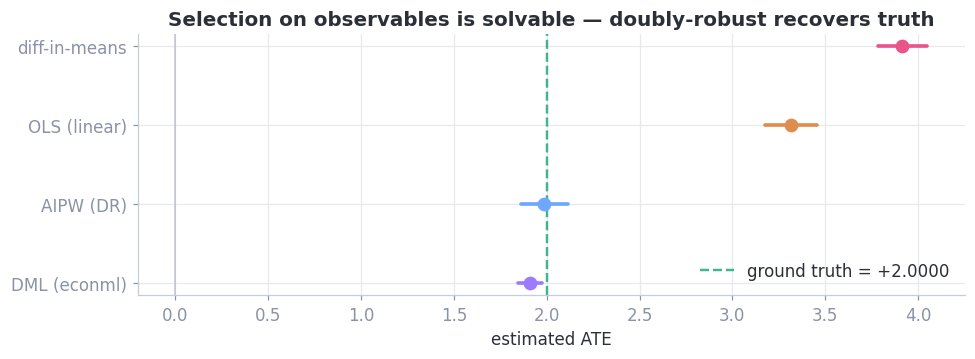

diff & OLS miss; AIPW & DML cover the dashed truth. The confounding is fully observed — so it is fixable.


In [3]:
fig, ax = plt.subplots(figsize=(9, 3.4))
forest(ax, res_obs, ["diff-in-means", "OLS (linear)", "AIPW (DR)", "DML (econml)"], truth=TRUTH,
       colors=[PINK, ORANGE, BLUE, PURPLE])
ax.set_xlabel("estimated ATE"); ax.set_title("Selection on observables is solvable — doubly-robust recovers truth")
plt.tight_layout(); plt.show()
print("diff & OLS miss; AIPW & DML cover the dashed truth. The confounding is fully observed — so it is fixable.")

**The reassuring picture, and exactly why it's dangerous.** AIPW and DML land on the truth — *as long as
X contains every confounder*. The estimator gives no warning if it doesn't. To see that, we have to author
a world where it doesn't.

## 3 · The honest half — a *hidden* confounder

Now plant a confounder **U** that drives both treatment and outcome but is **never recorded** — the panel
we hand the estimator omits it. To keep the demo clean, the observed baseline is **linear** in X (so OLS
is *correctly specified for the observables* — the only remaining problem is U):
$$e(X,U)=\sigma(c\,x_0 + a_U\,U),\qquad Y = b(X) + b_U\,U + \tau\,T + \varepsilon,\quad U\ \text{hidden}.$$
Because the same U pushes people *into* treatment and *up* in outcome, the treated look better than their
true counterfactual — and no adjustment on X can undo it.

In [4]:
class HiddenConfounderDGP:
    """Linear observed baseline + a HIDDEN confounder U driving both treatment and outcome. `sample`
    returns only X (U omitted); `ground_truth` knows τ *and* U's true confounding strength."""
    name = "hidden-U"

    def __init__(self, ate=2.0, d=4, sigma=1.0, c_x=0.9, a_u=1.3, b_u=2.0):
        self.ate, self.d, self.sigma, self.c_x, self.a_u, self.b_u = ate, d, sigma, c_x, a_u, b_u

    def _draw(self, n, seed):
        rng = np.random.default_rng(seed)
        X = rng.normal(0, 1, (n, self.d)); U = rng.normal(0, 1, n)
        e = sig(self.c_x * X[:, 0] + self.a_u * U)
        treat = (rng.random(n) < e).astype(int)
        b = 1.2 * X[:, 0] - 0.8 * X[:, 1] + 0.5 * X[:, 2]
        y = b + self.b_u * U + self.ate * treat + rng.normal(0, self.sigma, n)
        return X, U, treat, y

    def sample(self, n, seed):                       # U is NOT returned — it is unobserved
        X, U, treat, y = self._draw(n, seed)
        df = pd.DataFrame(X, columns=[f"x{j}" for j in range(self.d)])
        df.insert(0, "y", y); df.insert(0, "treat", treat)
        return df

    def oracle(self, n, seed):                       # with U revealed — for the meta-validation only
        X, U, treat, y = self._draw(n, seed)
        df = self.sample(n, seed).copy(); df["U"] = U
        return df

    def ground_truth(self):
        from lyra.protocols import GroundTruth
        return GroundTruth(ate=self.ate, extra={"a_u": self.a_u, "b_u": self.b_u})

dgp_hid = HiddenConfounderDGP(ate=2.0, a_u=1.3, b_u=2.0)
df_hid = dgp_hid.sample(6000, seed=2)

res_hid = [e.estimate(df_hid) for e in (DiffInMeans(), OLSAdjust(), AIPW(), DML())]
print(f"TRUTH ate = {dgp_hid.ate}  —  but U is hidden from every estimator")
for r in res_hid:
    print(f"  {r.estimator:6s} {r.point:+.3f}  CI [{r.ci[0]:+.2f},{r.ci[1]:+.2f}]   covers={r.covers(dgp_hid.ate)}")

TRUTH ate = 2.0  —  but U is hidden from every estimator
  diff   +4.550  CI [+4.43,+4.67]   covers=False
  ols    +4.012  CI [+3.90,+4.12]   covers=False
  aipw   +3.976  CI [+3.85,+4.10]   covers=False
  dml    +3.983  CI [+3.87,+4.09]   covers=False


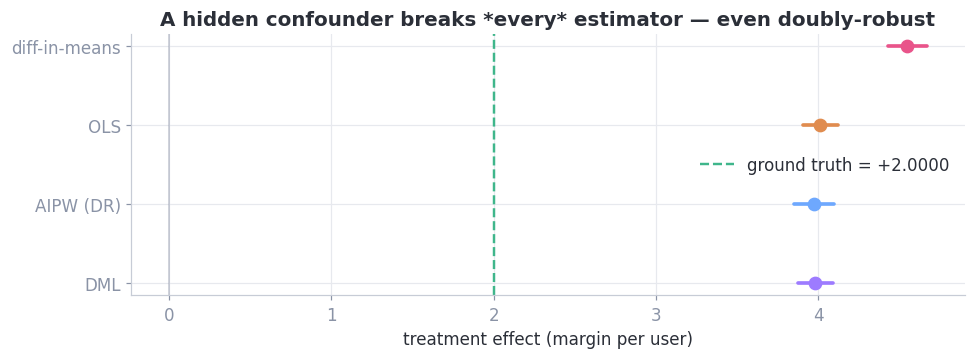

AIPW & DML — which nailed it under observed confounding — are now confidently wrong, with tight
intervals that exclude the truth. Nothing in the data flags this. Adjustment cannot remove what
it cannot see. This is the wall of observational inference.


In [5]:
fig, ax = plt.subplots(figsize=(9, 3.4))
forest(ax, res_hid, ["diff-in-means", "OLS", "AIPW (DR)", "DML"], truth=dgp_hid.ate,
       colors=[PINK, ORANGE, BLUE, PURPLE])
ax.set_title("A hidden confounder breaks *every* estimator — even doubly-robust")
plt.tight_layout(); plt.show()
print("AIPW & DML — which nailed it under observed confounding — are now confidently wrong, with tight\n"
      "intervals that exclude the truth. Nothing in the data flags this. Adjustment cannot remove what\n"
      "it cannot see. This is the wall of observational inference.")

## 4 · Sensitivity analysis — quantify the exposure you can't test away

We can't *prove* there is no U. What we *can* do is ask: **how strong would an unobserved confounder have
to be to overturn the result?** Two complementary tools live in `lyra.observational`:

- the **robustness value** RV — the minimal partial-R² a confounder must share with *both* treatment and
  outcome (beyond X) to drive the estimate to zero;
- the **omitted-variable-bias contour** — the worst-case adjusted estimate over all confounder strengths,
  whose 0-line is the "explained away" frontier.

We apply these to the **OLS-on-observables** fit (its t-statistic is the input to the closed form).

In [6]:
xcols = covariate_cols(df_hid)
X = sm.add_constant(df_hid[["treat", *xcols]].to_numpy(float))
m = sm.OLS(df_hid.y.to_numpy(float), X).fit(cov_type="HC1")
b_obs, se_obs = float(m.params[1]), float(m.bse[1]); t_obs = b_obs / se_obs; dof = int(m.df_resid)
RV = robustness_value(t_obs, dof)
print(f"observed (X-adjusted) estimate = {b_obs:+.3f}   [truth {dgp_hid.ate}]")
print(f"partial R²(treat ; y | X)      = {partial_r2(t_obs, dof):.3f}")
print(f"robustness value  RV(q=1)      = {RV:.3f}")
print(f"  → a confounder would need to explain ≥{RV:.0%} of the residual variance in BOTH treatment and")
print(f"    outcome (beyond X) to fully explain away the {b_obs:.2f} estimate.")
print(f"E-value (continuous)            = {e_value_smd(b_obs/df_hid.y.std()):.2f}")

observed (X-adjusted) estimate = +4.012   [truth 2.0]
partial R²(treat ; y | X)      = 0.472
robustness value  RV(q=1)      = 0.599
  → a confounder would need to explain ≥60% of the residual variance in BOTH treatment and
    outcome (beyond X) to fully explain away the 4.01 estimate.
E-value (continuous)            = 5.53


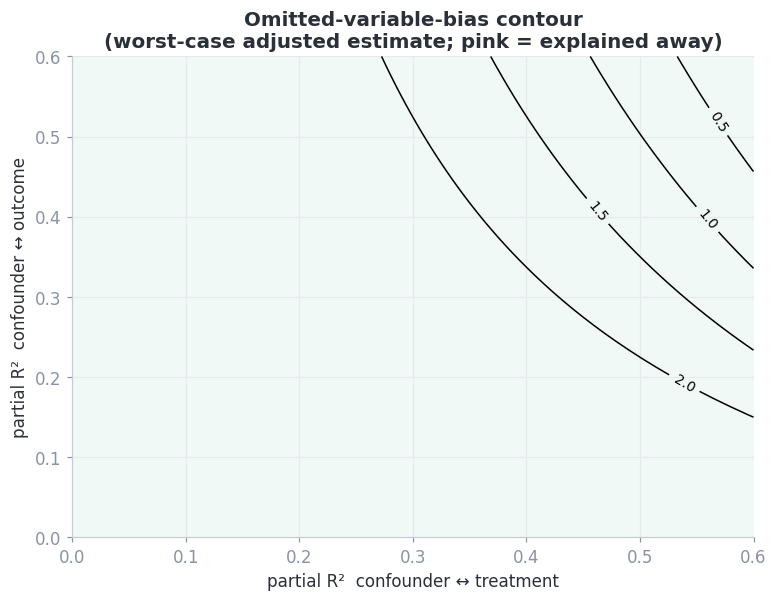

Read it as a map of doubt: any (strength-with-treatment, strength-with-outcome) point past the pink
line would push the estimate to zero. A confident result lives far inside the green region.


In [7]:
r2d, r2y, Z = ovb_contour(b_obs, se_obs, dof)
fig, ax = plt.subplots(figsize=(7.2, 5.6))
cs = ax.contour(r2d, r2y, Z, levels=[0.0, 0.5, 1.0, 1.5, 2.0], colors="k", linewidths=1)
ax.clabel(cs, fmt="%.1f", fontsize=9)
ax.contour(r2d, r2y, Z, levels=[0.0], colors=PINK, linewidths=2.6)             # the "explained away" line
ax.contourf(r2d, r2y, Z, levels=[0.0, 1e9], colors=[GREEN], alpha=0.07)
ax.set_xlabel("partial R²  confounder ↔ treatment"); ax.set_ylabel("partial R²  confounder ↔ outcome")
ax.set_title("Omitted-variable-bias contour\n(worst-case adjusted estimate; pink = explained away)")
plt.tight_layout(); plt.show()
print("Read it as a map of doubt: any (strength-with-treatment, strength-with-outcome) point past the pink\n"
      "line would push the estimate to zero. A confident result lives far inside the green region.")

## 5 · The superpower — validate the sensitivity analysis against ground truth

In a real study you'd *stop here* and argue about plausibility. But we **authored** U, so we can do
something no real analyst can: check whether the sensitivity math is **right**. We reveal U (the `oracle`),
measure its *true* partial-R² with treatment and outcome, feed those to the bias formula, and compare its
**predicted** bias to the **actual** bias the hidden U caused.

In [8]:
orc = dgp_hid.oracle(20_000, seed=2)
# U's true partial R² with the outcome (in y ~ treat + X + U) and with treatment (treat ~ X + U)
Xy = sm.add_constant(orc[["treat", *xcols, "U"]].to_numpy(float))
my = sm.OLS(orc.y.to_numpy(float), Xy).fit()
tU_y = float(my.tvalues[-1]); r2_yz = partial_r2(tU_y, int(my.df_resid))
Xt = sm.add_constant(orc[[*xcols, "U"]].to_numpy(float))
mt = sm.OLS(orc.treat.to_numpy(float), Xt).fit()
tU_t = float(mt.tvalues[-1]); r2_dz = partial_r2(tU_t, int(mt.df_resid))

predicted_bias = ovb_bias(se_obs, dof, r2_dz, r2_yz)
actual_bias = b_obs - dgp_hid.ate
print(f"U's TRUE strength:  partial R²(U;treat|X) = {r2_dz:.3f}   partial R²(U;y|X) = {r2_yz:.3f}")
print(f"  predicted bias from the OVB formula : {predicted_bias:+.3f}")
print(f"  actual bias the hidden U caused     : {actual_bias:+.3f}")
print(f"  → the sensitivity formula recovers the real bias to within {abs(predicted_bias-abs(actual_bias)):.3f}.")
print(f"\nU's true strength ({max(r2_dz, r2_yz):.2f}) vs the robustness value ({RV:.2f}): "
      f"U is {'STRONG enough to overturn' if min(r2_dz, r2_yz) > RV else 'NOT clearly past'} the RV bar.")

U's TRUE strength:  partial R²(U;treat|X) = 0.214   partial R²(U;y|X) = 0.760
  predicted bias from the OVB formula : +1.932
  actual bias the hidden U caused     : +2.012
  → the sensitivity formula recovers the real bias to within 0.080.

U's true strength (0.76) vs the robustness value (0.60): U is NOT clearly past the RV bar.


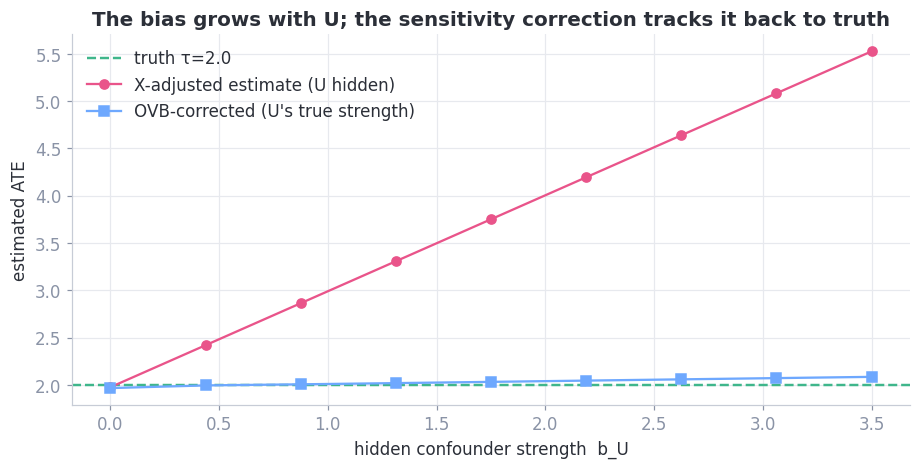

As U strengthens, the X-adjusted estimate drifts up; feeding U's *true* strength to the OVB formula
pulls it back onto the dashed truth. The sensitivity tool is itself certified against ground truth —
the discipline that makes an untestable assumption auditable.


In [9]:
# Sweep U's outcome-strength: does the OVB-predicted adjusted estimate track the truth the estimator misses?
strengths = np.linspace(0.0, 3.5, 9)
rows = []
for bu in strengths:
    d = HiddenConfounderDGP(ate=2.0, a_u=1.3, b_u=bu)
    s = d.sample(8000, seed=3); o = d.oracle(20000, seed=3)
    Xs = sm.add_constant(s[["treat", *xcols]].to_numpy(float))
    ms = sm.OLS(s.y.to_numpy(float), Xs).fit(cov_type="HC1")
    bb, ss = float(ms.params[1]), float(ms.bse[1]); dd = int(ms.df_resid)
    Xyo = sm.add_constant(o[["treat", *xcols, "U"]].to_numpy(float)); myo = sm.OLS(o.y.to_numpy(float), Xyo).fit()
    Xto = sm.add_constant(o[[*xcols, "U"]].to_numpy(float)); mto = sm.OLS(o.treat.to_numpy(float), Xto).fit()
    rdz = partial_r2(float(mto.tvalues[-1]), int(mto.df_resid)); ryz = partial_r2(float(myo.tvalues[-1]), int(myo.df_resid))
    rows.append({"b_u": bu, "naive_est": bb, "ovb_corrected": adjusted_estimate(bb, ss, dd, rdz, ryz)})
sw = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.axhline(2.0, color=GREEN, ls="--", lw=1.6, label="truth τ=2.0")
ax.plot(sw.b_u, sw.naive_est, "o-", color=PINK, label="X-adjusted estimate (U hidden)")
ax.plot(sw.b_u, sw.ovb_corrected, "s-", color=BLUE, label="OVB-corrected (U's true strength)")
ax.set_xlabel("hidden confounder strength  b_U"); ax.set_ylabel("estimated ATE")
ax.set_title("The bias grows with U; the sensitivity correction tracks it back to truth"); ax.legend()
plt.tight_layout(); plt.show()
print("As U strengthens, the X-adjusted estimate drifts up; feeding U's *true* strength to the OVB formula\n"
      "pulls it back onto the dashed truth. The sensitivity tool is itself certified against ground truth —\n"
      "the discipline that makes an untestable assumption auditable.")

### Two different questions — don't conflate them
Notice what just happened. The robustness value (0.60) and E-value (5.5) are **high** — they say *"a
confounder strong enough to make this effect **null** is implausible."* And they're **right**: the effect
is genuinely there (τ=2.0). But the same hidden U still **inflated the magnitude 2×** (4.0 vs 2.0). So:
- **RV / E-value** answer *"could a confounder explain the effect **away** (flip it to null)?"* — robustness
  of the **sign / existence**.
- **The OVB contour & bias formula** answer *"how **biased** is the magnitude?"* — and that's where the real
  exposure lived here.

A "robust" RV is *not* a clean bill of health for the number. Report both.

## 6 · Benchmarking — is a strong-enough U even plausible?

An RV is only useful next to a yardstick. The honest calibration: *how does the confounding U would need
compare to the confounders we actually measured?* If overturning the result needs a U many times stronger
than your most important observed covariate, the finding is robust; if a U as weak as `x0` would do it,
it's fragile.

In [10]:
# each observed covariate's partial R² with the outcome (its own t in the y~treat+X fit)
bench = []
for j, col in enumerate(xcols):
    tj = float(m.tvalues[2 + j])                          # 0=const,1=treat,2..=x0,x1,...
    bench.append({"covariate": col, "partial_R2_with_y": partial_r2(tj, dof)})
bench = pd.DataFrame(bench).sort_values("partial_R2_with_y", ascending=False)
strongest = bench.iloc[0]
print(f"RV = {RV:.3f}.  Strongest observed confounder: {strongest.covariate} "
      f"(partial R² with y = {strongest.partial_R2_with_y:.3f}).")
print(f"  → an unobserved U would need to be ~{RV/max(strongest.partial_R2_with_y,1e-6):.1f}× as strongly "
      f"associated with the outcome as {strongest.covariate} to explain the effect away.")
bench.round(3)

RV = 0.599.  Strongest observed confounder: x1 (partial R² with y = 0.134).
  → an unobserved U would need to be ~4.5× as strongly associated with the outcome as x1 to explain the effect away.


,covariate,partial_R2_with_y
1,x1,0.134
0,x0,0.126
2,x2,0.046
3,x3,0.000


## 7 · The applied proof — the music-marketing lab

This is the spine of the **`labs/music-marketing/`** identification study (`REPORT.md`). An MMM is
observational causal inference: marketing spend is **endogenous** (it chases releases already expected to
win) — textbook confounding. There, the discipline is the same as here:
- **adjust for observed structure** (a hierarchical baseline + per-channel response = the AIPW/DML role),
- **anchor with an experiment where you can** (a geo holdout = an instrument that breaks the endogeneity),
- and **score recovery against a planted ground truth** via a Monte-Carlo harness — the same `harness`
  used below — so the verdict is *measured*, not asserted.

The lab's headline (keep/cut decisions GO across the scarcity grid; magnitudes need data) is exactly this
notebook's lesson in a vertical: observational answers are usable **with** an honest account of what could
overturn them.

## 8 · Promotion gate — certify the estimators against ground truth

Every estimator ends behind the `Estimator` Protocol and earns a "certified: yes/no" from the same harness
the whole platform uses. Under **observed** confounding, the doubly-robust pair must recover truth with
nominal coverage; the naive pair must visibly fail (the bias is a *measured, asserted* quantity).

In [11]:
cert_dgp = DGPLevel1(d=5, ate=2.0, sigma=1.0, confounding=1.0, nonlinear=True)
cert = pd.DataFrame([harness(e, cert_dgp, R=120, n=2500) for e in (DiffInMeans(), OLSAdjust(), AIPW(), DML())])
cert["certified"] = (cert.coverage.between(0.90, 0.98)) & (cert.bias.abs() < 0.15)
print("Recovery of ATE=2.0 under observed (nonlinear) confounding — R=120 replicates:\n")
display = cert[["estimator", "bias", "rmse", "coverage", "certified"]].round(3)
display

Recovery of ATE=2.0 under observed (nonlinear) confounding — R=120 replicates:



,estimator,bias,rmse,coverage,certified
0,diff,1.791,1.795,0.000,False
1,ols,1.256,1.261,0.000,False
2,aipw,0.041,0.128,0.933,True
3,dml,-0.024,0.060,0.900,True


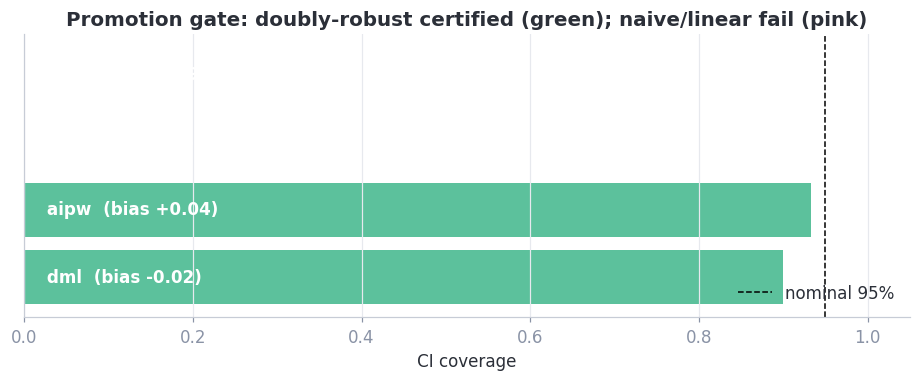

In [12]:
fig, ax = plt.subplots(figsize=(8.5, 3.6))
y = np.arange(len(cert))[::-1]
ax.barh(y, cert.coverage, color=[GREEN if c else PINK for c in cert.certified], alpha=.85)
ax.axvline(0.95, color="k", ls="--", lw=1, label="nominal 95%")
for yi, r in zip(y, cert.itertuples()):
    ax.text(0.02, yi, f" {r.estimator}  (bias {r.bias:+.2f})", va="center", color="white", fontweight="bold")
ax.set_yticks([]); ax.set_xlim(0, 1.05); ax.set_xlabel("CI coverage"); ax.legend(loc="lower right")
ax.set_title("Promotion gate: doubly-robust certified (green); naive/linear fail (pink)")
plt.tight_layout(); plt.show()

### Takeaways
- **Selection on observables is solvable** — AIPW/DML recover the ATE under nonlinear confounding; naive
  and linear adjustment do not. That half is engineering.
- **Selection on unobservables is unfalsifiable** — a hidden confounder breaks *every* estimator and leaves
  no diagnostic trace. The only honest response is **sensitivity analysis**: the robustness value, the OVB
  contour, the E-value, and benchmarking against measured confounders.
- **Because we author the world, we can certify the sensitivity analysis itself** — the OVB formula recovers
  the true bias a known hidden confounder injects. That is the Lyra discipline applied one level up.
- The **music-marketing lab** is this notebook made concrete: observational measurement is decision-useful
  when shipped *with* its sensitivity story, not instead of one.

*Promoted module:* `lyra/observational.py` (`DML`, `robustness_value`, `ovb_bias`, `ovb_contour`,
`e_value`). *Next:* the same sensitivity layer wraps the incrementality leg (NB 12) and the marketplace.